# Q1: Heart disease classification

Goal: predict heart_disease where 1 means disease present and 0 means absent.

Game plan for this notebook:
- do a quick sanity check on data quality
- train a few baseline tree models
- compare precision, recall, and F1 before picking a final model

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

sns.set(style="whitegrid")


In [7]:
df = pd.read_csv("../data/q1_heart_disease.csv")

# Task 1: Data loading and inspection
print("shape:", df.shape)

print("\ndata types:\n", df.dtypes)

print("\nmissing values per column:\n", df.isna().sum())

# Show first five rows
df.head()


shape: (800, 12)

data types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

missing values per column:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Quick EDA

Before modeling, I want to check class balance and whether any obvious numeric relationships jump out.

<ipython-input-8-a769da847461>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="heart_disease", palette="viridis")


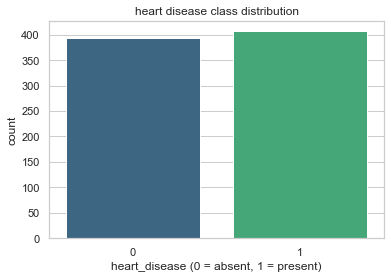

In [8]:
# Target class distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="heart_disease", palette="viridis")
plt.title("heart disease class distribution")
plt.xlabel("heart_disease (0 = absent, 1 = present)")
plt.ylabel("count")
plt.show()


### Note on class balance
Nice to see this is close to balanced: **407** positives vs **393** negatives. That means accuracy won’t be overly misleading, and precision/recall/F1 should be informative.

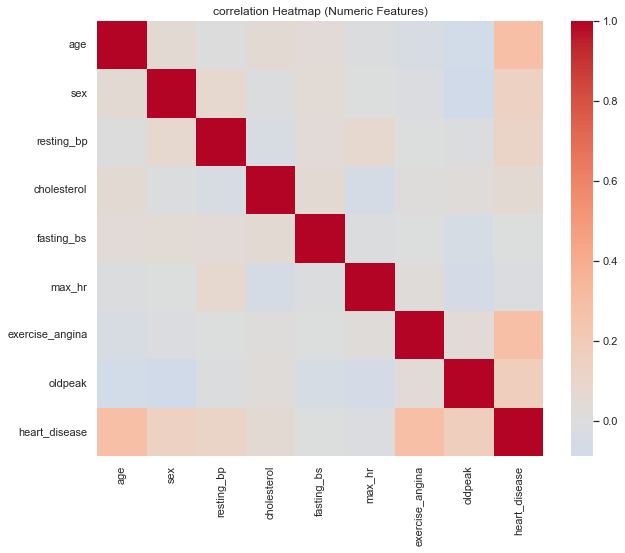

In [9]:
# Correlation heatmap (numeric features only)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("correlation Heatmap (Numeric Features)")
plt.show()


### Interpretation (correlation heatmap)
Most numeric feature correlations are **weak** (values near 0). That suggests relationships between features are not strongly linear, so models that can capture non-linear patterns (e.g., tree-based ensembles and boosting) may be better suited than purely linear approaches. Also, there’s no obvious severe multicollinearity among numeric predictors.

<ipython-input-10-85a5c68046d2>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="heart_disease", y="age", palette="Set2")


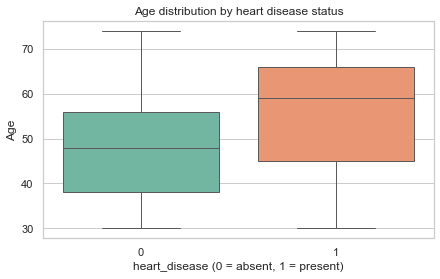

In [10]:
# Additional visualization: Age distribution by class
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="heart_disease", y="age", palette="Set2")
plt.title("Age distribution by heart disease status")
plt.xlabel("heart_disease (0 = absent, 1 = present)")
plt.ylabel("Age")
plt.show()


### Interpretation (age vs. target)
Patients with heart_disease=1 tend to be older than those without the disease. The median and the overall spread of age are shifted higher for the positive class, indicating that age may be a useful signal for classification.

## Preprocessing choices

I’m using simple, reliable defaults here:
- Numeric columns: median imputation (less sensitive to outliers).
- Categorical columns: most-frequent imputation.
- No row dropping, because missingness is small and I’d rather keep sample size.

In [13]:
X = df.drop(columns=["heart_disease"])
y = df["heart_disease"]

# Identify column types
categorical_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
numeric_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
)
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']
Categorical columns: ['chest_pain_type', 'resting_ecg', 'st_slope']


## Task 4 & 5: Model Training and Evaluation

In [14]:
models = {
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
    "Random Forest Classifier": RandomForestClassifier(random_state=42),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=42),
}

model_results = {}

for name, model in models.items():
    clf = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n=== {name} ===")
    print("Confusion Matrix (rows=true, cols=pred) [[TN, FP], [FN, TP]]:")
    print(cm)
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")

    model_results[name] = {
        "pipeline": clf,
        "cm": cm,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }

# Determine best model by F1-score
best_model_name = max(model_results, key=lambda k: model_results[k]["f1"])
best_model_name



=== Decision Tree Classifier ===
Confusion Matrix (rows=true, cols=pred) [[TN, FP], [FN, TP]]:
[[56 23]
 [22 59]]
Precision: 0.7195
Recall:    0.7284
F1-score:  0.7239

=== Random Forest Classifier ===
Confusion Matrix (rows=true, cols=pred) [[TN, FP], [FN, TP]]:
[[60 19]
 [15 66]]
Precision: 0.7765
Recall:    0.8148
F1-score:  0.7952

=== Gradient Boosting Classifier ===
Confusion Matrix (rows=true, cols=pred) [[TN, FP], [FN, TP]]:
[[61 18]
 [18 63]]
Precision: 0.7778
Recall:    0.7778
F1-score:  0.7778


'Random Forest Classifier'

### Which model wins?
On this split, Random Forest is the strongest option.

- Decision Tree: F1 = 0.7239
- Random Forest: F1 = 0.7952
- Gradient Boosting: F1 = 0.7778

I will tune Random Forest next because it gives the best precision and recall balance on the positive class.

In [15]:
# Task 6: Hyperparameter tuning on the best-performing model
baseline_metrics = model_results[best_model_name]
print("\nBaseline untuned test metrics for:", best_model_name)
print("Confusion Matrix:", baseline_metrics["cm"])
print(f"Precision: {baseline_metrics['precision']:.4f}")
print(f"Recall:    {baseline_metrics['recall']:.4f}")
print(f"F1-score:  {baseline_metrics['f1']:.4f}")

# Define parameter grid for the best model
if best_model_name == "Decision Tree Classifier":
    param_grid = {
        "model__max_depth": [None, 2, 3, 4, 5, 6],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    }
    base_model = DecisionTreeClassifier(random_state=42)

elif best_model_name == "Random Forest Classifier":
    param_grid = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 4, 6, 8, 10],
        "model__min_samples_split": [2, 5, 10],
    }
    base_model = RandomForestClassifier(random_state=42)

else:
    param_grid = {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
    }
    base_model = GradientBoostingClassifier(random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=Pipeline(steps=[("preprocess", preprocess), ("model", base_model)]),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("\nBest parameters found:")
print(grid_search.best_params_)

tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
prec_tuned = precision_score(y_test, y_pred_tuned, zero_division=0)
rec_tuned = recall_score(y_test, y_pred_tuned, zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, zero_division=0)

print("\nTuned test-set performance:")
print("Confusion Matrix:")
print(cm_tuned)
print(f"Precision: {prec_tuned:.4f}")
print(f"Recall:    {rec_tuned:.4f}")
print(f"F1-score:  {f1_tuned:.4f}")

print("\nChange vs baseline:")
print(f"F1: {baseline_metrics['f1']:.4f} -> {f1_tuned:.4f}")
print(f"Precision: {baseline_metrics['precision']:.4f} -> {prec_tuned:.4f}")
print(f"Recall: {baseline_metrics['recall']:.4f} -> {rec_tuned:.4f}")



Baseline untuned test metrics for: Random Forest Classifier
Confusion Matrix: [[60 19]
 [15 66]]
Precision: 0.7765
Recall:    0.8148
F1-score:  0.7952

Best parameters found:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Tuned test-set performance:
Confusion Matrix:
[[59 20]
 [14 67]]
Precision: 0.7701
Recall:    0.8272
F1-score:  0.7976

Change vs baseline:
F1: 0.7952 -> 0.7976
Precision: 0.7765 -> 0.7701
Recall: 0.8148 -> 0.8272


### Tuning impact
Tuning helped, but only a little: F1 moved from **0.7952 -> 0.7976**.

The bigger change is recall improving (**0.8148 -> 0.8272**), which means fewer missed disease cases. Precision dipped a bit (**0.7765 -> 0.7701**), which is a reasonable trade-off in this setting.